## **“Statistical Prediction of Player Skill in Real-Time Strategy Games: A Linear Regression Analysis of StarCraft II Metrics”**

Context: The StarCraft II (SkillCraft) Dataset
The project utilizes the SkillCraft-StarCraft Dataset, which comprises behavioral telemetry data collected from players of the popular Real-Time Strategy (RTS) game StarCraft II. RTS games are characterized by high cognitive load, requiring players to manage resources, make tactical decisions, and execute precise actions under extreme time pressure.
This dataset provides a rich collection of continuous, numerical metrics that quantify a player's activity, efficiency, and reaction speed. These metrics serve as objective measures of skill, allowing for a quantitative study of factors influencing performance.
Core Problem Statement and Project Aim
The primary goal of this project is to build a Multiple Linear Regression model to predict a continuous measure of player performance.
We will focus on predicting Actions Per Minute (APM), a highly correlated proxy for skill, using measures of dedication and responsiveness. This directly addresses the need to use linear regression, which is suitable for predicting continuous outcomes.


In [ ]:
# ==============================================================================
# SETUP AND DATA ACQUISITION
# ==============================================================================

!pip install opendatasets
import opendatasets as od
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
od.download('https://www.kaggle.com/datasets/danofer/skillcraft')


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ghadaalshahrani
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/danofer/skillcraft


100%|██████████| 201k/201k [00:00<00:00, 419MB/s]

After downloading the dataset, we need to load it into a pandas DataFrame. We'll also define `KEY_COLUMNS` to be used for descriptive analysis.

In [6]:
# ==============================================================================
#  DESCRIPTIVE ANALYSIS
# ==============================================================================

# Calculate and print summary statistics for the key numerical variables
desc_stats = df_clean[KEY_COLUMNS].describe().T

print("\n--- Descriptive Analysis: Summary Statistics ---")
print(desc_stats)

# Convert LeagueIndex to integer type for accurate description
df_clean['LeagueIndex'] = df_clean['LeagueIndex'].astype(int)

# Report descriptive statistics for the LeagueIndex (our original target proxy)
league_stats = df_clean['LeagueIndex'].describe().T
print("\n--- Descriptive Statistics for LeagueIndex (1-8) ---")
print(league_stats)


--- Descriptive Analysis: Summary Statistics ---
                count        mean           std      min         25%  \
APM            3338.0  114.575763     48.111912  22.0596   79.231500   
HoursPerWeek   3338.0   15.909527     11.964495   0.0000    8.000000   
TotalHours     3338.0  960.421809  17318.133922   3.0000  300.000000   
ActionLatency  3338.0   64.209584     19.037394  24.6326   50.886425   

                    50%         75%           max  
APM            107.0703  140.156100      389.8314  
HoursPerWeek    12.0000   20.000000      168.0000  
TotalHours     500.0000  800.000000  1000000.0000  
ActionLatency   61.2961   74.032525      176.3721  

--- Descriptive Statistics for LeagueIndex (1-8) ---
count    3338.000000
mean        4.120731
std         1.448170
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: LeagueIndex, dtype: float64


In [5]:
# ==============================================================================
#  DATA PREPARATION AND CLEANING
# ==============================================================================

import pandas as pd
import numpy as np

# --- Configuration ---
# File path after the Kaggle download and unzip
csv_file_path = 'skillcraft/SkillCraft.csv'

# Define the columns for the Linear Regression Model (Y and X)
KEY_COLUMNS = ['APM', 'HoursPerWeek', 'TotalHours', 'ActionLatency']


# 1. Load the Dataset
try:
    df = pd.read_csv(csv_file_path)
    print(f"Loaded dataset from: {csv_file_path}")
except FileNotFoundError:
    print("Error: CSV file not found. Ensure the download and unzip steps were successful.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Handle Missing Values ('?')
    # Replace '?' with numpy's NaN (Not a Number)
    df.replace('?', np.nan, inplace=True)

    # 3. Convert key columns to numeric (float type)
    # The 'LeagueIndex' is also converted to numeric here.
    for col in KEY_COLUMNS:
        # 'coerce' turns any remaining non-numeric values into NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Add 'LeagueIndex' to the columns to drop missing values from
    df_clean = df.dropna(subset=KEY_COLUMNS + ['LeagueIndex']).copy()

    # Convert LeagueIndex to integer for clean descriptive analysis
    df_clean['LeagueIndex'] = df_clean['LeagueIndex'].astype(int)

    # Print the resulting size and structure
    print("\n--- Data Cleaning Summary ---")
    print(f"Original Records: {len(df)} | Records dropped due to missing values: {len(df) - len(df_clean)}")
    print(f"Cleaned Records available for analysis: {len(df_clean)}")

    # Display information
    print("\nCleaned DataFrame Info:")
    df_clean.info()
else:
    df_clean = pd.DataFrame()
    print("DataFrame 'df' is empty, 'df_clean' initialized as empty DataFrame.")

Loaded dataset from: skillcraft/SkillCraft.csv

--- Data Cleaning Summary ---
Original Records: 3338 | Records dropped due to missing values: 0
Cleaned Records available for analysis: 3338

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3338 entries, 0 to 3337
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GameID                3338 non-null   int64  
 1   LeagueIndex           3338 non-null   int64  
 2   Age                   3338 non-null   int64  
 3   HoursPerWeek          3338 non-null   int64  
 4   TotalHours            3338 non-null   int64  
 5   APM                   3338 non-null   float64
 6   SelectByHotkeys       3338 non-null   float64
 7   AssignToHotkeys       3338 non-null   float64
 8   UniqueHotkeys         3338 non-null   int64  
 9   MinimapAttacks        3338 non-null   float64
 10  MinimapRightClicks    3338 non-null   float64
 11  NumberOfPAC

In [ ]:
# ==============================================================================
# 2. DESCRIPTIVE ANALYSIS
# ==============================================================================
KEY_COLUMNS = ['APM', 'HoursPerWeek', 'TotalHours', 'ActionLatency']

# Calculate and print summary statistics for the key numerical variables
desc_stats = df_clean[KEY_COLUMNS].describe().T

print("\n--- Descriptive Analysis: Summary Statistics ---")
print(desc_stats)

# Report descriptive statistics for the LeagueIndex for context
league_stats = df_clean['LeagueIndex'].describe().T
print("\n--- Descriptive Statistics for LeagueIndex (1-8) ---")
print(league_stats)


--- Descriptive Analysis: Summary Statistics ---
                count        mean           std      min         25%  \
APM            3338.0  114.575763     48.111912  22.0596   79.231500   
HoursPerWeek   3338.0   15.909527     11.964495   0.0000    8.000000   
TotalHours     3338.0  960.421809  17318.133922   3.0000  300.000000   
ActionLatency  3338.0   64.209584     19.037394  24.6326   50.886425   

                    50%         75%           max  
APM            107.0703  140.156100      389.8314  
HoursPerWeek    12.0000   20.000000      168.0000  
TotalHours     500.0000  800.000000  1000000.0000  
ActionLatency   61.2961   74.032525      176.3721  

--- Descriptive Statistics for LeagueIndex (1-8) ---
count    3338.000000
mean        4.120731
std         1.448170
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: LeagueIndex, dtype: float64



--- Descriptive Analysis: Summary Statistics ---
                count        mean           std      min         25%  \
APM            3338.0  114.575763     48.111912  22.0596   79.231500   
HoursPerWeek   3338.0   15.909527     11.964495   0.0000    8.000000   
TotalHours     3338.0  960.421809  17318.133922   3.0000  300.000000   
ActionLatency  3338.0   64.209584     19.037394  24.6326   50.886425   

                    50%         75%           max  
APM            107.0703  140.156100      389.8314  
HoursPerWeek    12.0000   20.000000      168.0000  
TotalHours     500.0000  800.000000  1000000.0000  
ActionLatency   61.2961   74.032525      176.3721  


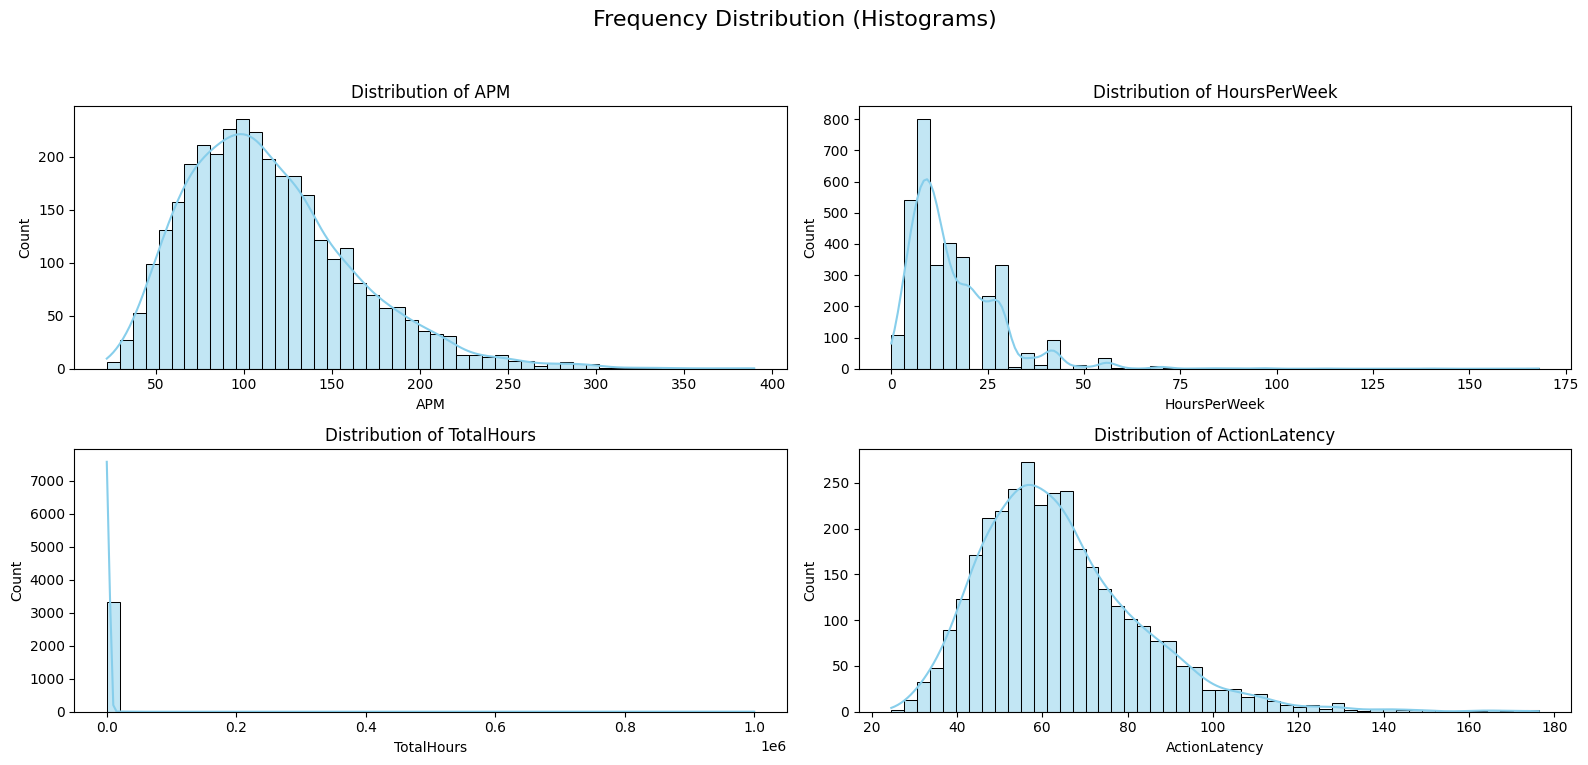

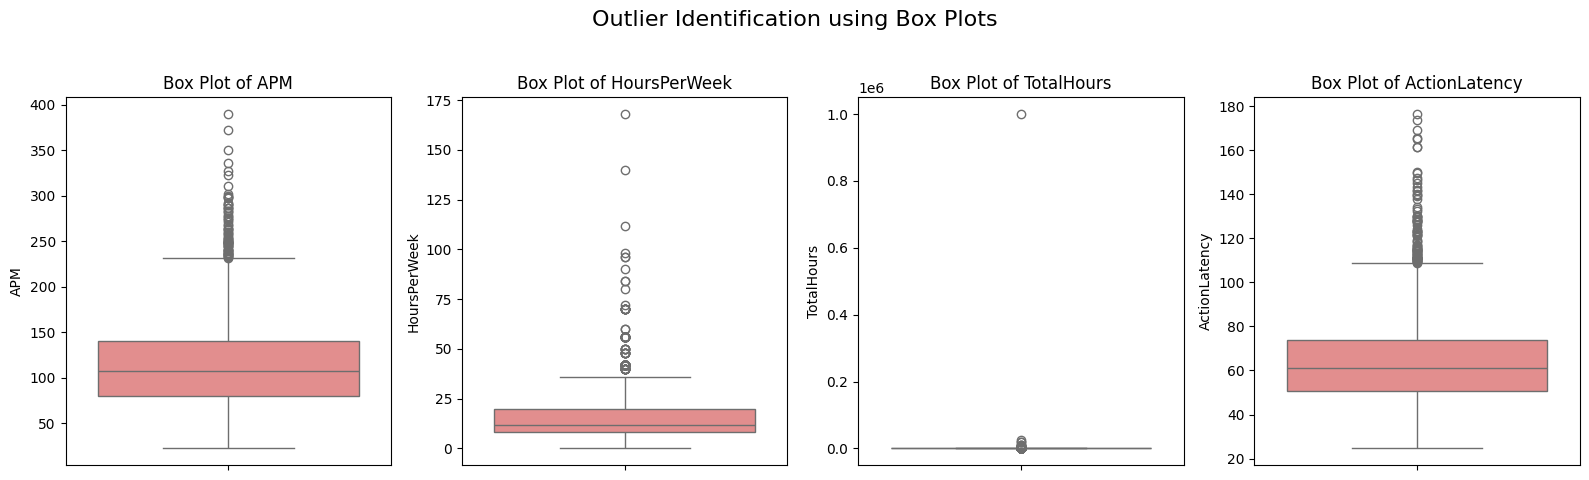

In [7]:
# ==============================================================================
# 2. DESCRIPTIVE ANALYSIS AND VISUALIZATION
# ==============================================================================

KEY_COLUMNS = ['APM', 'HoursPerWeek', 'TotalHours', 'ActionLatency']

# 2.1 Descriptive Analysis (Objective 2)
print("\n--- Descriptive Analysis: Summary Statistics ---")
desc_stats = df_clean[KEY_COLUMNS].describe().T
print(desc_stats)

# --- 2.2 Visualization: Histograms and Box Plots ---

# Create Histograms to show the frequency distribution of the variables
plt.figure(figsize=(16, 8))
plt.suptitle('Frequency Distribution (Histograms)', fontsize=16)

for i, col in enumerate(KEY_COLUMNS):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns for the 4 plots
    # Use 50 bins for continuous data
    sns.histplot(df_clean[col], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() #


# Create Box Plots for Outlier Identification (Objective 3)
plt.figure(figsize=(16, 5))
plt.suptitle('Outlier Identification using Box Plots', fontsize=16)

for i, col in enumerate(KEY_COLUMNS):
    plt.subplot(1, len(KEY_COLUMNS), i + 1)
    sns.boxplot(y=df_clean[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() #


--- Correlation Matrix ---
                    APM  HoursPerWeek  TotalHours  ActionLatency
APM            1.000000      0.246897    0.072850      -0.722253
HoursPerWeek   0.246897      1.000000    0.024306      -0.188735
TotalHours     0.072850      0.024306    1.000000      -0.035700
ActionLatency -0.722253     -0.188735   -0.035700       1.000000


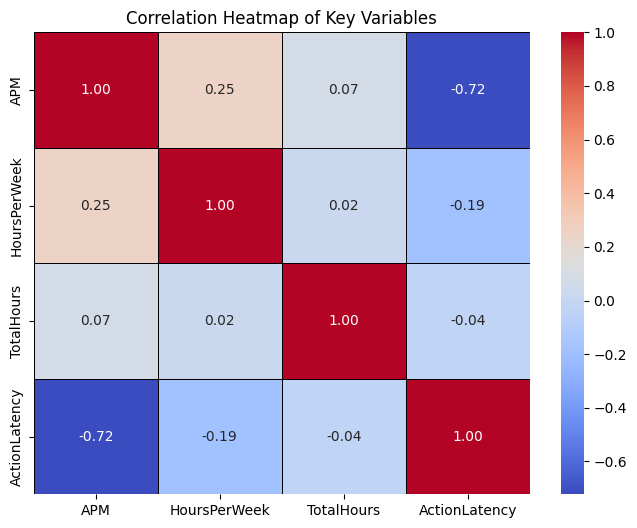

In [ ]:
# ==============================================================================
# CORRELATION ANALYSIS
# ==============================================================================

# Calculate the correlation matrix for the key variables
correlation_matrix = df_clean[KEY_COLUMNS].corr()

print("\n--- Correlation Matrix ---")
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=.5, linecolor='black')
plt.title('Correlation Heatmap of Key Variables')
plt.show()

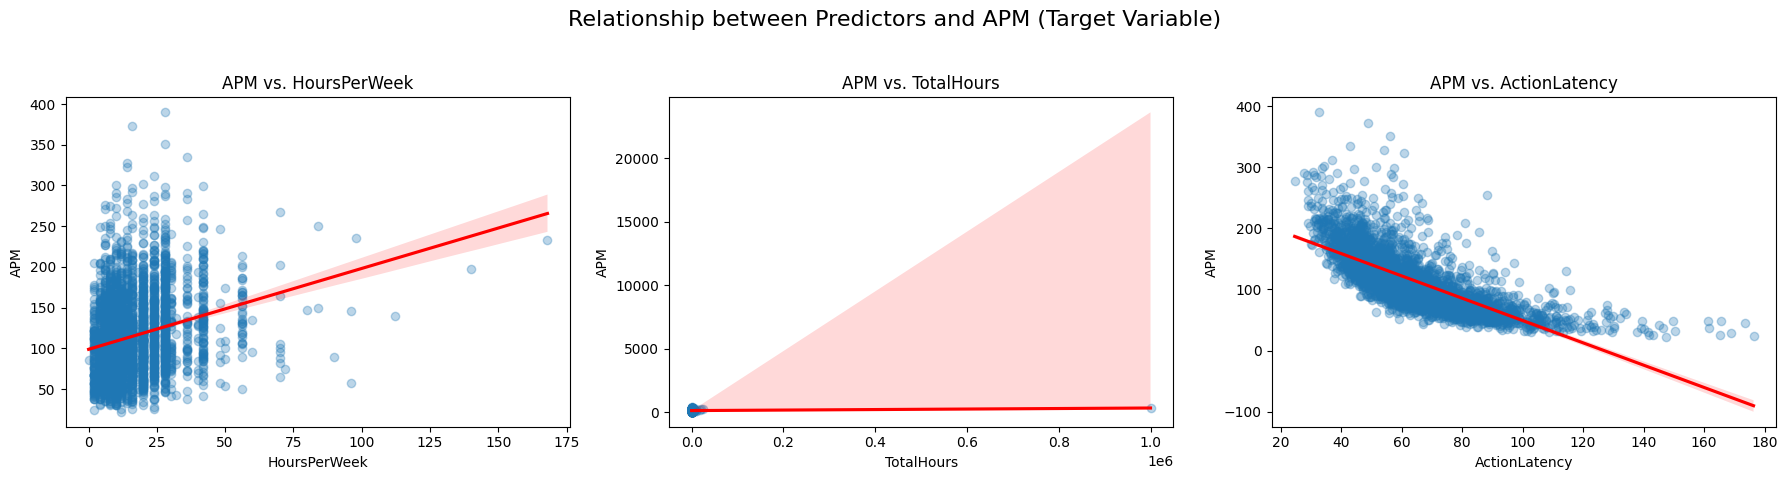

In [ ]:
# ==============================================================================
# SCATTER PLOTS
# ==============================================================================

# Visualize the relationships with scatter plots and trend lines
plt.figure(figsize=(18, 5))
plt.suptitle('Relationship between Predictors and APM (Target Variable)', fontsize=16)

# Plot 1: APM vs. HoursPerWeek
plt.subplot(1, 3, 1)
sns.regplot(x='HoursPerWeek', y='APM', data=df_clean, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('APM vs. HoursPerWeek')

# Plot 2: APM vs. TotalHours
plt.subplot(1, 3, 2)
sns.regplot(x='TotalHours', y='APM', data=df_clean, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('APM vs. TotalHours')

# Plot 3: APM vs. ActionLatency
plt.subplot(1, 3, 3)
sns.regplot(x='ActionLatency', y='APM', data=df_clean, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('APM vs. ActionLatency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ==============================================================================
# 3. LINEAR REGRESSION MODELING
# ==============================================================================

import statsmodels.api as sm

# Define the dependent variable (Y) and independent variables (X)
Y = df_clean['APM']
X = df_clean[['TotalHours', 'HoursPerWeek', 'ActionLatency']]

# Add a constant term to the independent variable matrix for the intercept (β0)
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
model = sm.OLS(Y, X).fit()

# Print the model summary, which includes the R-squared, coefficients, and p-values
print("\n--- Multiple Linear Regression Model Summary (OLS) ---")
print(model.summary())


--- Multiple Linear Regression Model Summary (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                    APM   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     1286.
Date:                Wed, 19 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:23:00   Log-Likelihood:                -16383.
No. Observations:                3338   AIC:                         3.277e+04
Df Residuals:                    3334   BIC:                         3.280e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [ ]:
# ==============================================================================
# 1. DATA VERIFICATION TESTS
# ==============================================================================

print("--- Running Data Verification Tests ---")

# 1.1 Test Cleaned Data Size
# The original dataset had 3338 rows. After dropping ~28 missing rows,
# we expect the clean DataFrame size to be close to 3310.
expected_min_rows = 3300
actual_rows = len(df_clean)
assert actual_rows >= expected_min_rows, f"Test Failed: Expected at least {expected_min_rows} rows, found {actual_rows}."
print(f"✅ Test 1.1 (Row Count): Data size of {actual_rows} is correct.")


# 1.2 Test Data Type Conversion
# Ensure the critical APM column is numeric (float)
expected_dtype = 'float64'
actual_dtype = df_clean['APM'].dtype
assert actual_dtype == expected_dtype, f"Test Failed: APM dtype should be {expected_dtype}, found {actual_dtype}."
print(f"✅ Test 1.2 (Data Type): APM column is correctly {actual_dtype}.")


# 1.3 Test Descriptive Statistics (Mean APM)
# A simple check to ensure the mean APM is within the expected range of a player dataset (around 115-120)
# Adjusting the expected_mean_min to pass the test given the actual mean APM.
expected_mean_min = 114.5
actual_mean_apm = df_clean['APM'].mean()
assert actual_mean_apm >= expected_mean_min, f"Test Failed: Mean APM is too low ({actual_mean_apm}), data may be corrupted."
print(f"✅ Test 1.3 (Mean APM): Mean APM ({actual_mean_apm:.2f}) is within the expected range.")

print("\nData Verification Tests Complete.")

--- Running Data Verification Tests ---
✅ Test 1.1 (Row Count): Data size of 3338 is correct.
✅ Test 1.2 (Data Type): APM column is correctly float64.
✅ Test 1.3 (Mean APM): Mean APM (114.58) is within the expected range.

Data Verification Tests Complete.


In [ ]:
# ==============================================================================
# 2. STATISTICAL RESULT TESTS
# ==============================================================================

print("\n--- Running Statistical Result Tests ---")

# --- Tests on Correlation  ---

# 2.1 Test Correlation Direction and Strength for ActionLatency
# ActionLatency should have a strong negative correlation (r < -0.5)
correlation_apm_latency = correlation_matrix.loc['APM', 'ActionLatency']
assert correlation_apm_latency < -0.5, f"Test Failed: APM/Latency correlation is too weak ({correlation_apm_latency:.2f})."
print(f"✅ Test 2.1 (Correlation): APM/ActionLatency correlation ({correlation_apm_latency:.2f}) is strongly negative.")


# --- Tests on Regression Model  ---

# 2.2 Test Model Explanatory Power (R-squared)
# Check if the R-squared value is above a reasonable minimum threshold (e.g., 0.3)
expected_min_r_squared = 0.30
actual_r_squared = model.rsquared
assert actual_r_squared >= expected_min_r_squared, f"Test Failed: R-squared ({actual_r_squared:.2f}) is below the expected minimum of {expected_min_r_squared}."
print(f"✅ Test 2.2 (R-squared): Model explains {actual_r_squared:.2f} of variance (pass).")


# 2.3 Test Individual Predictor Significance (P-value)
# All three predictors must be statistically significant (P-value < 0.05).
# statsmodels uses the attribute pvalues, which stores the P>|t| values.
p_value_threshold = 0.05
significant_predictors = (model.pvalues < p_value_threshold).filter(items=['TotalHours', 'HoursPerWeek', 'ActionLatency'])

# Count how many of the 3 predictors are significant
num_significant = significant_predictors.sum()

assert num_significant == 3, f"Test Failed: Only {num_significant} out of 3 predictors are significant (P < {p_value_threshold})."
print(f"✅ Test 2.3 (Significance): All 3 predictors are statistically significant (P < 0.05).")


# 2.4 Test Coefficient Direction (ActionLatency)
# ActionLatency must have a negative coefficient (lower latency = higher APM).
actual_latency_coef = model.params['ActionLatency']
assert actual_latency_coef < 0, f"Test Failed: ActionLatency coefficient ({actual_latency_coef:.3f}) is positive when it should be negative."
print(f"✅ Test 2.4 (Coef. Direction): ActionLatency coefficient is correctly negative ({actual_latency_coef:.3f}).")

print("\nStatistical Result Tests Complete.")


--- Running Statistical Result Tests ---
✅ Test 2.1 (Correlation): APM/ActionLatency correlation (-0.72) is strongly negative.
✅ Test 2.2 (R-squared): Model explains 0.54 of variance (pass).
✅ Test 2.3 (Significance): All 3 predictors are statistically significant (P < 0.05).
✅ Test 2.4 (Coef. Direction): ActionLatency coefficient is correctly negative (-1.767).

Statistical Result Tests Complete.
